# How many people survived over the age of 30

this observational study would find out if age was a contributing factor to survival, 30years of age is considered the end of an adult humans "prime" and is when their physical capabilities begin detororating. would this have influenced survival rates?

In [105]:
import pandas as pd

df2 = pd.read_csv("titanic.csv")
df2.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [125]:
df = pd.read_csv("titanic.csv")
df_30plus = df[df["Age"] >= 31].reset_index(drop=True)
print(f"Total passengers age 30+: {len(df_30plus)}")
print(f"Survivors age 30+: {(df_30plus['Survived'] == 1).sum()}")
print(f"Non-survivors age 30+: {(df_30plus['Survived'] == 0).sum()}")
print(f"Survival rate (30+): {(df_30plus['Survived'] == 1).sum() / len(df_30plus) * 100:.1f}%")
print("page break but words")
df_sub30 = df[df["Age"] <= 30].reset_index(drop=True)
colors = ['green' if x == 1 else 'red' for x in df_sub30["Survived"]]
print(f"Total passengers age <30: {len(df_sub30)}")
print(f"Survivors age <30: {(df_sub30['Survived'] == 1).sum()}")
print(f"Non-survivors age <30: {(df_sub30['Survived'] == 0).sum()}")
print(f"Survival rate (<30): {(df_sub30['Survived'] == 1).sum() / len(df_sub30) * 100:.1f}%")

Total passengers age 30+: 303
Survivors age 30+: 124
Non-survivors age 30+: 179
Survival rate (30+): 40.9%
page break but words
Total passengers age <30: 409
Survivors age <30: 166
Non-survivors age <30: 243
Survival rate (<30): 40.6%


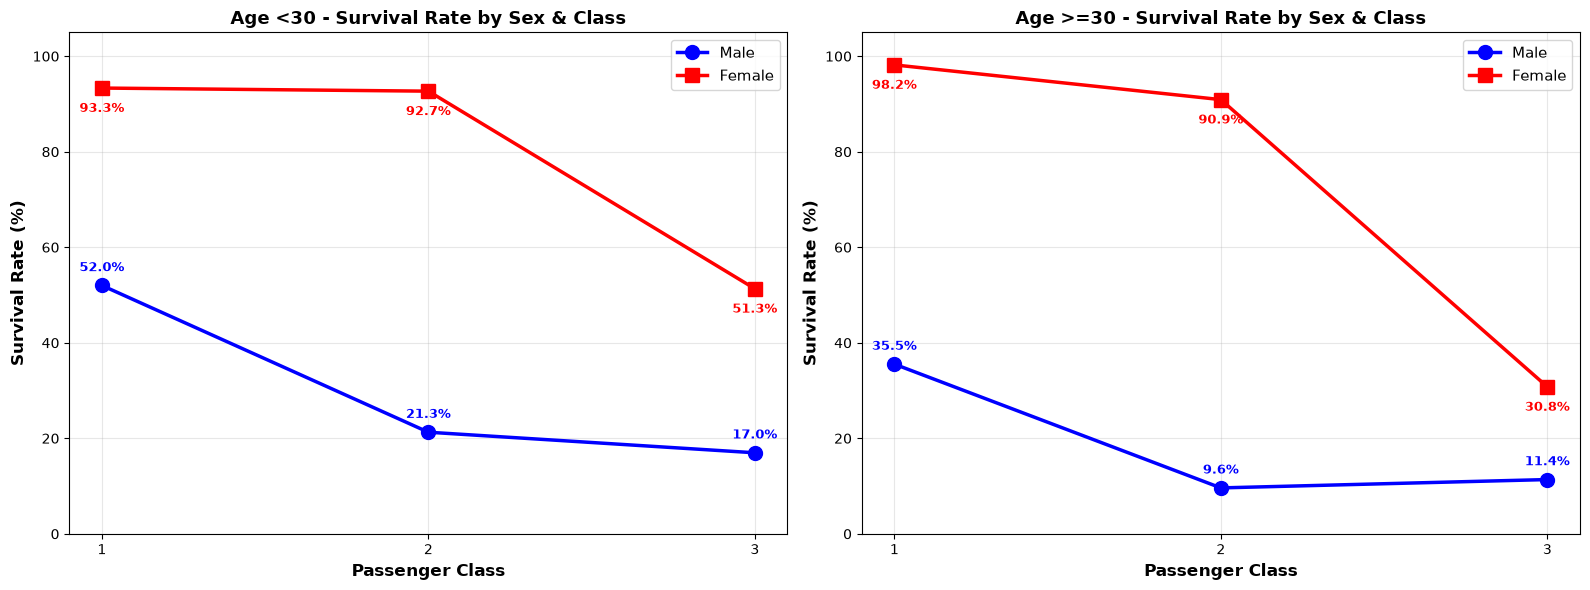


TITANIC SURVIVAL STATISTICS BY SEX, CLASS, AND AGE GROUP

----------------------------AGE GROUP: <30----------------------------
----------------------------------------------------------------------

  MALE:
    Class 1: 13/25 survived (52.0%)
    Class 2: 10/47 survived (21.3%)
    Class 3: 28/165 survived (17.0%)

  FEMALE:
    Class 1: 28/30 survived (93.3%)
    Class 2: 38/41 survived (92.7%)
    Class 3: 39/76 survived (51.3%)

---------------------------AGE GROUP: >=30----------------------------
----------------------------------------------------------------------

  MALE:
    Class 1: 27/76 survived (35.5%)
    Class 2: 5/52 survived (9.6%)
    Class 3: 10/88 survived (11.4%)

  FEMALE:
    Class 1: 54/55 survived (98.2%)
    Class 2: 30/33 survived (90.9%)
    Class 3: 8/26 survived (30.8%)



In [126]:
#claude insanity
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the dataset
df = pd.read_csv("titanic.csv")

# Create age group column
df['Age_Group'] = df['Age'].apply(lambda x: '<30' if x < 30 else '>=30' if pd.notna(x) else 'Unknown')

# Remove rows with missing age
df_clean = df[df['Age_Group'] != 'Unknown'].copy()

plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loop through age groups
age_groups = ['<30', '>=30']

for idx, age_group in enumerate(age_groups):
    ax = axes[idx]
    
    # Filter by age group
    df_age = df_clean[df_clean['Age_Group'] == age_group]
    
    # Calculate survival rates for each combination of Sex and Class
    classes = sorted(df_age['Pclass'].unique())
    males_survival = []
    females_survival = []
    
    for pclass in classes:
        # Male survival rate
        male_data = df_age[(df_age['Pclass'] == pclass) & (df_age['Sex'] == 'male')]
        if len(male_data) > 0:
            male_rate = (male_data['Survived'] == 1).sum() / len(male_data) * 100
        else:
            male_rate = 0
        males_survival.append(male_rate)
        
        # Female survival rate
        female_data = df_age[(df_age['Pclass'] == pclass) & (df_age['Sex'] == 'female')]
        if len(female_data) > 0:
            female_rate = (female_data['Survived'] == 1).sum() / len(female_data) * 100
        else:
            female_rate = 0
        females_survival.append(female_rate)
    
    # Plot lines
    ax.plot(classes, males_survival, marker='o', linewidth=2.5, markersize=10, label='Male', color='blue')
    ax.plot(classes, females_survival, marker='s', linewidth=2.5, markersize=10, label='Female', color='red')
    
    # Labels and formatting
    ax.set_xlabel('Passenger Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Age {age_group} - Survival Rate by Sex & Class', fontsize=13, fontweight='bold')
    ax.set_xticks(classes)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='best')
    
    # Add value labels on points
    for i, (cls, m_rate, f_rate) in enumerate(zip(classes, males_survival, females_survival)):
        ax.text(cls, m_rate + 3, f'{m_rate:.1f}%', ha='center', fontsize=9, color='blue', fontweight='bold')
        ax.text(cls, f_rate - 5, f'{f_rate:.1f}%', ha='center', fontsize=9, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("TITANIC SURVIVAL STATISTICS BY SEX, CLASS, AND AGE GROUP")
print("="*70)

for age_group in age_groups:
    df_age = df_clean[df_clean['Age_Group'] == age_group]
    print(f"\n{'AGE GROUP: ' + age_group:-^70}")
    print("-"*70)
    
    for sex in ['male', 'female']:
        print(f"\n  {sex.upper()}:")
        for pclass in sorted(df_age['Pclass'].unique()):
            subset = df_age[(df_age['Pclass'] == pclass) & (df_age['Sex'] == sex)]
            if len(subset) > 0:
                survivors = (subset['Survived'] == 1).sum()
                total = len(subset)
                rate = survivors / total * 100
                print(f"    Class {int(pclass)}: {survivors}/{total} survived ({rate:.1f}%)")

print("\n" + "="*70)

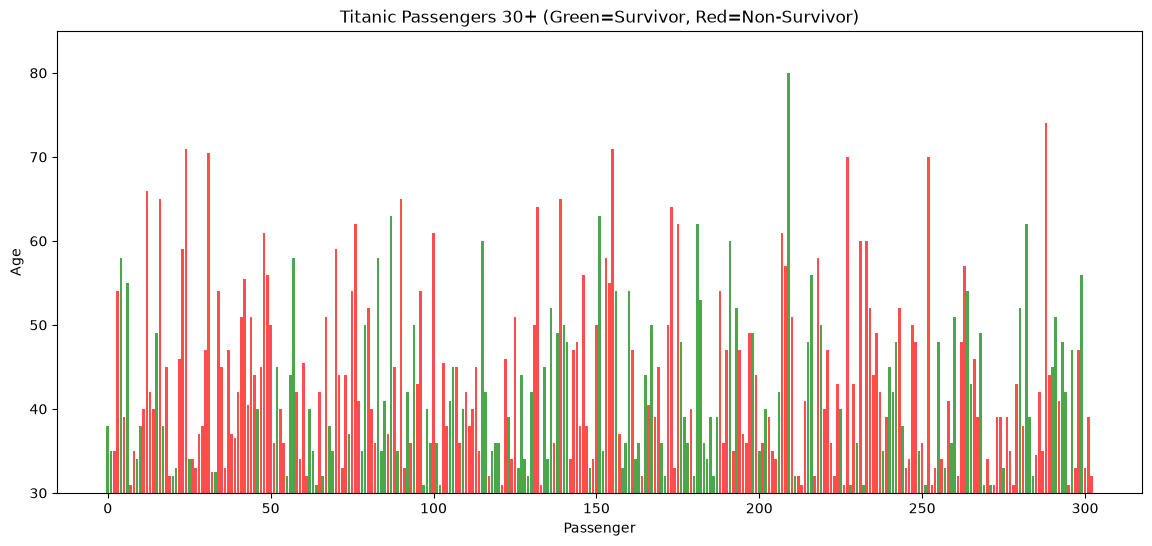

Total passengers age 30+: 303
Survivors age 30+: 124
Non-survivors age 30+: 179
Survival rate (30+): 40.9%


In [107]:
# claude
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("titanic.csv")
df_30plus = df[df["Age"] >= 31].reset_index(drop=True)
colors = ['green' if x == 1 else 'red' for x in df_30plus["Survived"]]

plt.close("all")
plt.figure(figsize=(14, 6))
plt.bar(range(len(df_30plus)), df_30plus["Age"], color=colors, alpha=0.7)
plt.ylim(30, df_30plus["Age"].max() + 5)
plt.xlabel("Passenger")
plt.ylabel("Age")
plt.title("Titanic Passengers 30+ (Green=Survivor, Red=Non-Survivor)")
plt.show()
# Print summary statistics
print(f"Total passengers age 30+: {len(df_30plus)}")
print(f"Survivors age 30+: {(df_30plus['Survived'] == 1).sum()}")
print(f"Non-survivors age 30+: {(df_30plus['Survived'] == 0).sum()}")
print(f"Survival rate (30+): {(df_30plus['Survived'] == 1).sum() / len(df_30plus) * 100:.1f}%")

C:\Users\khinkle2\AppData\Local\Temp\ipykernel_11028\1988426197.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_30plus = df2[df["Age"] >= 60].reset_index(drop=True)


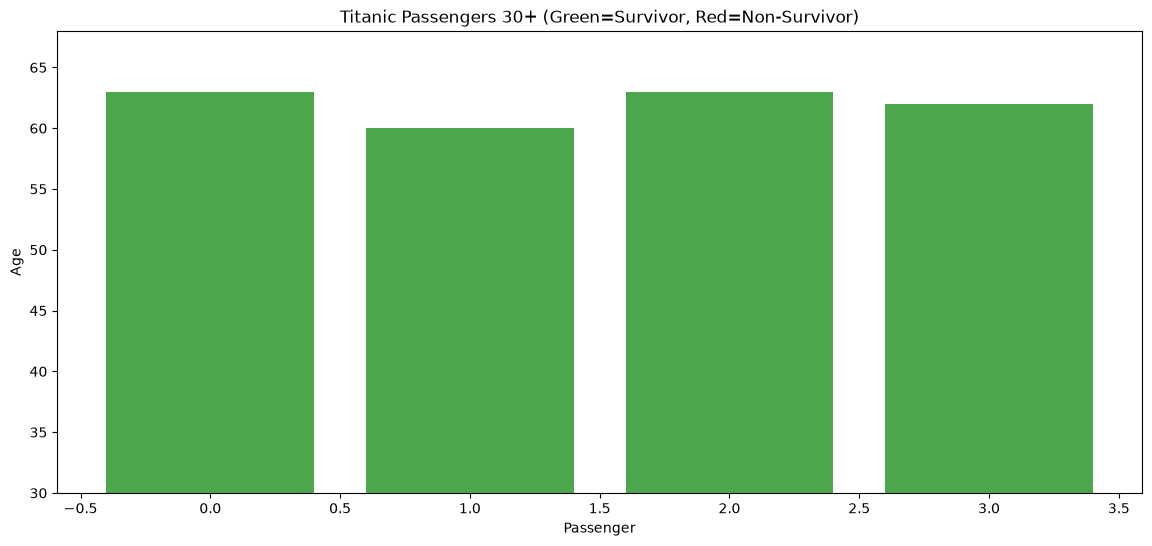

Total passengers age 30+: 4
Survivors age 30+: 4
Non-survivors age 30+: 0
Survival rate (30+): 100.0%


In [120]:
# claude
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("titanic.csv")
df2 = df[df["Sex"] == "female"]
df_30plus = df2[df["Age"] >= 60].reset_index(drop=True)
colors = ['green' if x == 1 else 'red' for x in df_30plus["Survived"]]

plt.close("all")
plt.figure(figsize=(14, 6))
plt.bar(range(len(df_30plus)), df_30plus["Age"], color=colors, alpha=0.7)
plt.ylim(30, df_30plus["Age"].max() + 5)
plt.xlabel("Passenger")
plt.ylabel("Age")
plt.title("Titanic Passengers 30+ (Green=Survivor, Red=Non-Survivor)")
plt.show()
# Print summary statistics
print(f"Total passengers age 30+: {len(df_30plus)}")
print(f"Survivors age 30+: {(df_30plus['Survived'] == 1).sum()}")
print(f"Non-survivors age 30+: {(df_30plus['Survived'] == 0).sum()}")
print(f"Survival rate (30+): {(df_30plus['Survived'] == 1).sum() / len(df_30plus) * 100:.1f}%")

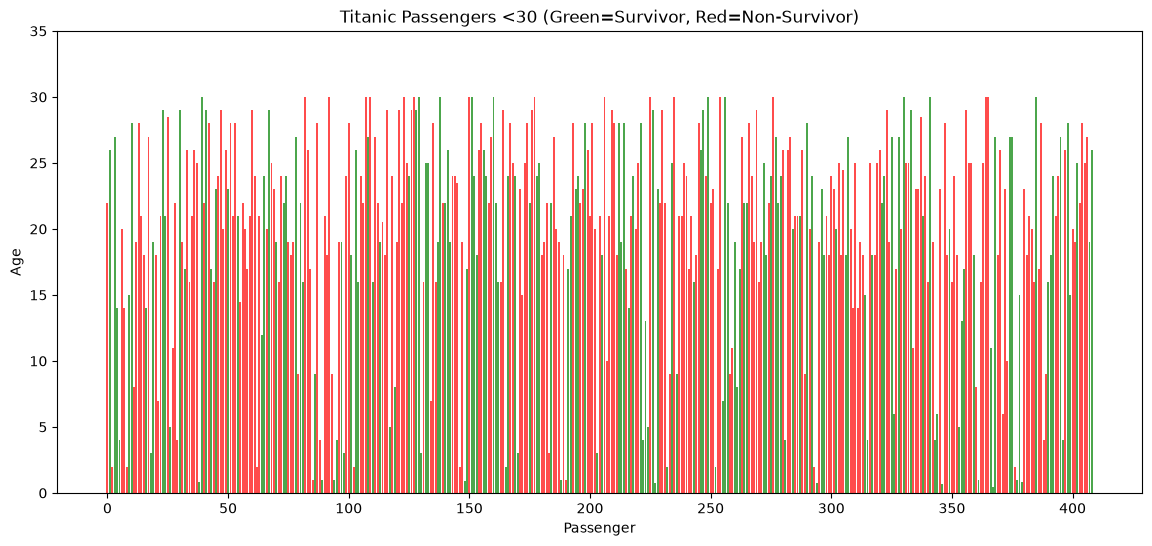

Total passengers age <30: 409
Survivors age <30: 166
Non-survivors age <30: 243
Survival rate (<30): 40.6%


In [111]:
# Claude modified
# Print summary statistics
df_sub30 = df[df["Age"] <= 30].reset_index(drop=True)
colors = ['green' if x == 1 else 'red' for x in df_sub30["Survived"]]

plt.close("all")
plt.figure(figsize=(14, 6))
plt.bar(range(len(df_sub30)), df_sub30["Age"], color=colors, alpha=0.7)
plt.ylim(0, df_sub30["Age"].max() + 5)
plt.xlabel("Passenger")
plt.ylabel("Age")
plt.title("Titanic Passengers <30 (Green=Survivor, Red=Non-Survivor)")
plt.show()
print(f"Total passengers age <30: {len(df_sub30)}")
print(f"Survivors age <30: {(df_sub30['Survived'] == 1).sum()}")
print(f"Non-survivors age <30: {(df_sub30['Survived'] == 0).sum()}")
print(f"Survival rate (<30): {(df_sub30['Survived'] == 1).sum() / len(df_sub30) * 100:.1f}%")

C:\Users\khinkle2\AppData\Local\Temp\ipykernel_11028\1154498520.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sub30 = df2[df["Age"] <= 30].reset_index(drop=True)


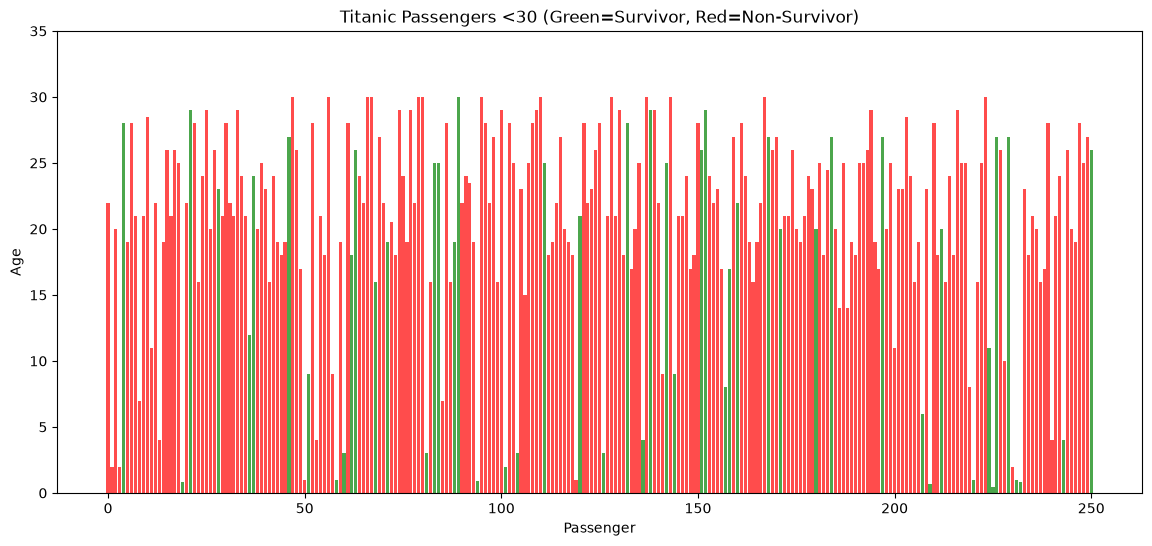

Total passengers age <30: 251
Survivors age <30: 52
Non-survivors age <30: 199
Survival rate (<30): 20.7%


In [113]:
# Claude modified
# Print summary statistics
df2 = df[df["Sex"] == "male"]
df_sub30 = df2[df["Age"] <= 30].reset_index(drop=True)
colors = ['green' if x == 1 else 'red' for x in df_sub30["Survived"]]

plt.close("all")
plt.figure(figsize=(14, 6))
plt.bar(range(len(df_sub30)), df_sub30["Age"], color=colors, alpha=0.7)
plt.ylim(0, df_sub30["Age"].max() + 5)
plt.xlabel("Passenger")
plt.ylabel("Age")
plt.title("Titanic Passengers <30 (Green=Survivor, Red=Non-Survivor)")
plt.show()
print(f"Total passengers age <30: {len(df_sub30)}")
print(f"Survivors age <30: {(df_sub30['Survived'] == 1).sum()}")
print(f"Non-survivors age <30: {(df_sub30['Survived'] == 0).sum()}")
print(f"Survival rate (<30): {(df_sub30['Survived'] == 1).sum() / len(df_sub30) * 100:.1f}%")

C:\Users\khinkle2\AppData\Local\Temp\ipykernel_11028\2456580927.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sub30 = df2[df["Age"] <= 30].reset_index(drop=True)


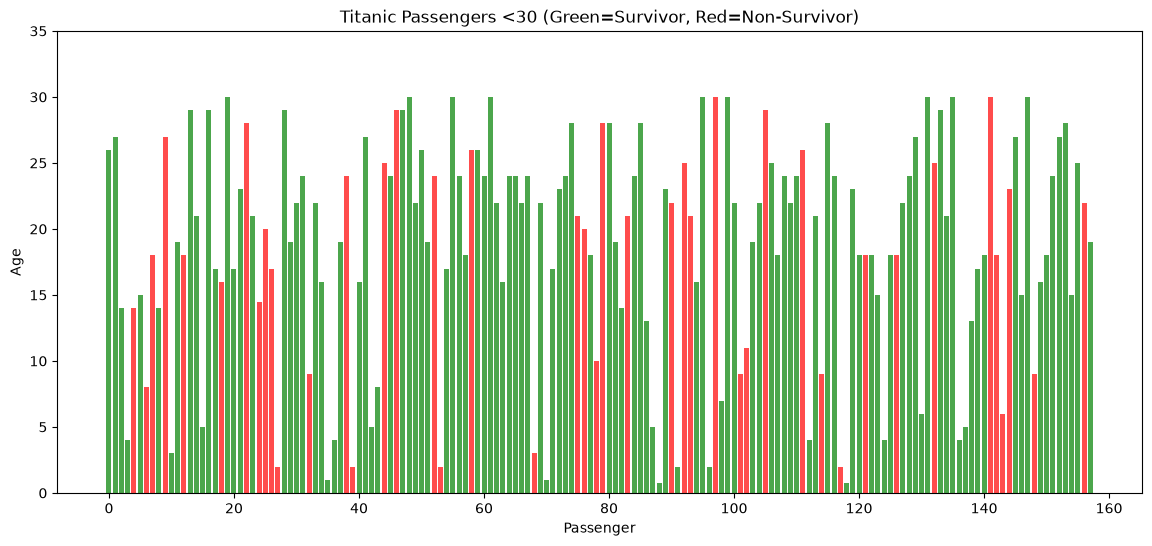

Total passengers age <30: 158
Survivors age <30: 114
Non-survivors age <30: 44
Survival rate (<30): 72.2%


In [116]:
# Claude modified
# Print summary statistics
df2 = df[df["Sex"] == "female"]
df_sub30 = df2[df["Age"] <= 30].reset_index(drop=True)
colors = ['green' if x == 1 else 'red' for x in df_sub30["Survived"]]

plt.close("all")
plt.figure(figsize=(14, 6))
plt.bar(range(len(df_sub30)), df_sub30["Age"], color=colors, alpha=0.7)
plt.ylim(0, df_sub30["Age"].max() + 5)
plt.xlabel("Passenger")
plt.ylabel("Age")
plt.title("Titanic Passengers <30 (Green=Survivor, Red=Non-Survivor)")
plt.show()
print(f"Total passengers age <30: {len(df_sub30)}")
print(f"Survivors age <30: {(df_sub30['Survived'] == 1).sum()}")
print(f"Non-survivors age <30: {(df_sub30['Survived'] == 0).sum()}")
print(f"Survival rate (<30): {(df_sub30['Survived'] == 1).sum() / len(df_sub30) * 100:.1f}%")